# Project 07 - RAG: Retrieval-Augmented Generation

RAG is the single most-used pattern in production LLM systems. We build a **working mini-RAG**
here with simple tools so every step runs and the retrieval is real, then give you the
**production code** (real embeddings + a vector database + an LLM) for Kaggle/your machine.

**What you'll learn**
- Why we bolt **retrieval** onto an LLM (to stop it making things up).
- **Chunking**, **embeddings**, **semantic search**, and building an **augmented prompt**.
- How to retrieve the right passage for a question - and SEE the similarity scores.

## The scenario
Your company has a help centre full of policy documents. You want a chatbot that answers
customer questions **using only those documents**, with citations - not the LLM's vague memory.
That's RAG: **retrieve** the relevant passages, then ask the LLM to answer **grounded** in them.

## Foundations (plain English)
- **Why RAG?** An LLM alone answers from fuzzy memory and can **hallucinate** (state false things
  confidently). RAG feeds it the *actual* relevant text, so answers are grounded and citable.
- **Chunking**: long documents are split into bite-sized passages so we can retrieve just the
  relevant part.
- **Embeddings**: each chunk is turned into a vector so that *similar meaning = nearby vectors*.
  (Here we use TF-IDF vectors as a simple stand-in; real systems use neural embedding models.)
- **Semantic search**: embed the question too, then find the chunks whose vectors are closest
  (highest cosine similarity).
- **Augmented prompt**: paste the retrieved chunks + the question into the LLM prompt and ask it
  to answer using only that context, citing sources.

### Cell 1 - imports and a tiny knowledge base
Six short 'policy' passages. In a real project these come from your PDFs/docs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD

docs = [
 "Refunds are processed within 5 to 7 business days after we receive the returned item.",
 "Standard shipping takes 3 to 5 business days; express shipping arrives next business day.",
 "Our products come with a 2 year warranty covering manufacturing defects.",
 "You can cancel your subscription anytime from the account settings page.",
 "Customer support is available 24/7 via live chat and email.",
 "We accept credit cards, debit cards, UPI, and net banking for payments.",
]
print(f"{len(docs)} passages in the knowledge base")

6 passages in the knowledge base


### Cell 2 - chunking (splitting long text into passages)
Real documents are long, so we split them into overlapping chunks. Overlap keeps sentences that
straddle a boundary from being lost. Here's a simple word-window chunker on a longer paragraph.

In [2]:
def chunk(text, size=12, overlap=4):
    words = text.split(); out = []; i = 0
    while i < len(words):
        out.append(" ".join(words[i:i+size])); i += size - overlap
    return out

long_doc = ("Our return policy lets you send items back within 30 days. "
            "Refunds are processed within 5 to 7 business days after we receive the item. "
            "Shipping fees are non refundable unless the item arrived damaged.")
for j, c in enumerate(chunk(long_doc)):
    print(f"chunk {j}: {c}")

chunk 0: Our return policy lets you send items back within 30 days. Refunds
chunk 1: within 30 days. Refunds are processed within 5 to 7 business days
chunk 2: to 7 business days after we receive the item. Shipping fees are
chunk 3: item. Shipping fees are non refundable unless the item arrived damaged.
chunk 4: item arrived damaged.


### Cell 3 - embed everything and build the search index
We fit a TF-IDF vectorizer on the passages - that turns each into a numeric vector. The 'index'
is just these vectors; searching = comparing the question's vector to them.

In [3]:
vec = TfidfVectorizer()
doc_vectors = vec.fit_transform(docs)        # the 'embeddings' of our knowledge base
print("each passage is now a vector of length", doc_vectors.shape[1])

each passage is now a vector of length 58


### Cell 4 - retrieve: find the passages closest to a question
We embed the question with the SAME vectorizer, compute cosine similarity to every passage, and
take the top matches. This is semantic search in miniature.

In [4]:
def retrieve(question, k=2):
    qv = vec.transform([question])
    sims = cosine_similarity(qv, doc_vectors)[0]      # similarity to each passage
    top = sims.argsort()[::-1][:k]
    return top, sims

question = "How long does it take to get my money back after a return?"
top, sims = retrieve(question)
print("Question:", question, "\n")
for rank, i in enumerate(top, 1):
    print(f"#{rank} (score {sims[i]:.2f}): {docs[i]}")

Question: How long does it take to get my money back after a return? 

#1 (score 0.38): Refunds are processed within 5 to 7 business days after we receive the returned item.
#2 (score 0.14): Standard shipping takes 3 to 5 business days; express shipping arrives next business day.


### Cell 5 - diagram: similarity scores (why those passages won)
The bar chart shows how similar each passage is to the question. The retrieved (top-k) passages
are highlighted - you can literally see the system pick the refund passage over the others.

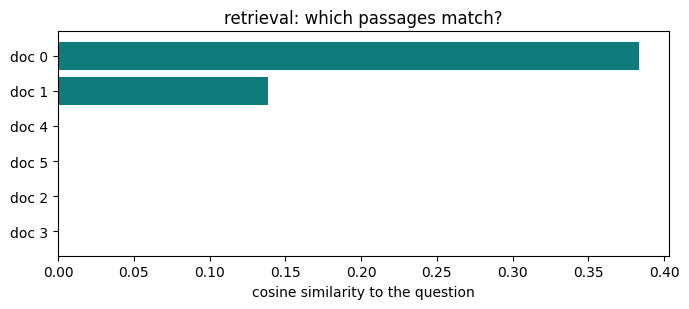

In [5]:
order = sims.argsort()[::-1]
colors = ["#0e7c7b" if i in top else "#c9ced9" for i in order]
plt.figure(figsize=(7,3.2))
plt.barh([f"doc {i}" for i in order][::-1], sims[order][::-1], color=colors[::-1])
plt.xlabel("cosine similarity to the question"); plt.title("retrieval: which passages match?")
plt.tight_layout(); plt.show()

### Cell 6 - diagram: the knowledge base as a map
We squeeze the vectors down to 2D and plot the passages plus the question (red star). The
question lands nearest the passages we retrieved - that closeness IS the retrieval.

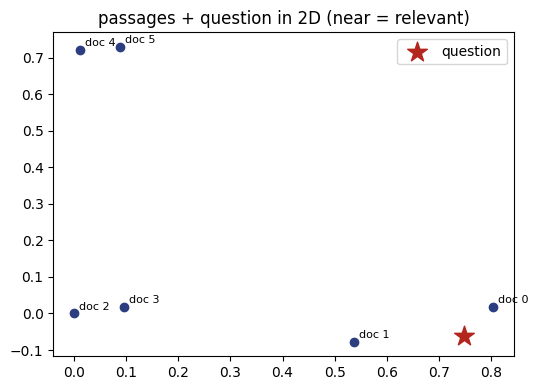

In [6]:
both = vec.transform([question])
allv = np.vstack([doc_vectors.toarray(), both.toarray()])
xy = TruncatedSVD(n_components=2, random_state=0).fit_transform(allv)
plt.figure(figsize=(5.5,4))
plt.scatter(xy[:-1,0], xy[:-1,1], color="#2d3e80")
for i,(x,y) in enumerate(xy[:-1]): plt.text(x+0.01,y+0.01,f"doc {i}",fontsize=8)
plt.scatter(xy[-1,0], xy[-1,1], color="#b3261e", marker="*", s=220, label="question")
plt.legend(); plt.title("passages + question in 2D (near = relevant)"); plt.tight_layout(); plt.show()

### Cell 7 - assemble the augmented prompt (what the LLM actually sees)
RAG's final step: stuff the retrieved passages into a prompt with the question, and instruct the
LLM to answer **only** from that context and cite sources. Below we BUILD that prompt (we don't
call an LLM here - on Kaggle/your machine you'd send this to one).

In [7]:
context = "\n".join(f"[{i}] {docs[i]}" for i in top)
prompt = f'''Answer the question using ONLY the context. Cite sources like [0].
If the answer isn't in the context, say you don't know.

Context:
{context}

Question: {question}
Answer:'''
print(prompt)
print("\n--- an LLM would now generate, e.g. ---")
print("Refunds take 5 to 7 business days after we receive the returned item. [0]")

Answer the question using ONLY the context. Cite sources like [0].
If the answer isn't in the context, say you don't know.

Context:
[0] Refunds are processed within 5 to 7 business days after we receive the returned item.
[1] Standard shipping takes 3 to 5 business days; express shipping arrives next business day.

Question: How long does it take to get my money back after a return?
Answer:

--- an LLM would now generate, e.g. ---
Refunds take 5 to 7 business days after we receive the returned item. [0]


## The real thing - production RAG (run on Kaggle or locally)
Swap TF-IDF for a real neural embedding model and a vector database, and plug in an LLM. The
*shape* is identical to what you just built.

```python
# pip install llama-index llama-index-embeddings-huggingface chromadb
from llama_index.core import VectorStoreIndex, SimpleDirectoryReader, Settings
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

Settings.embed_model = HuggingFaceEmbedding("BAAI/bge-small-en-v1.5")   # real embeddings
docs  = SimpleDirectoryReader("data/policies").load_data()              # your PDFs/markdown
index = VectorStoreIndex.from_documents(docs)                           # chunk + embed + store
engine = index.as_query_engine(similarity_top_k=3)                      # retrieval
print(engine.query("How long do refunds take?"))                       # grounded, cited answer
```

**Make it production-grade (the project's real goal):**
- **Hybrid search + re-ranking:** combine keyword (BM25) + vector search, then a cross-encoder
  re-ranker for precision.
- **Evaluate, don't vibe-check:** measure *faithfulness* and *answer relevance* with RAGAS:
```python
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy
# evaluate(dataset_of_q_a_contexts, metrics=[faithfulness, answer_relevancy])
```
- **Serve it:** wrap in FastAPI, add a Gradio chat UI, containerize with Docker (data/ops edge).

## What just happened (recap)
1. We **chunked** documents and **embedded** them into vectors.
2. We **retrieved** the closest passages to a question (and saw the scores + a 2D map).
3. We built the **augmented prompt** an LLM uses to answer grounded, with citations.
The production version swaps in neural embeddings + a vector DB + an LLM, and adds re-ranking,
RAGAS evaluation, and serving.

## Extensions
- **Ask another question** (e.g. about warranty) and watch the retrieved passage change.
- **No-answer case:** ask something not in the docs - a good RAG system should say "I don't know".
- **Chunk size matters:** too big = noisy context; too small = lost meaning. Tune it.
- **Project goal:** build real RAG over your IIT-J notes or product docs, measure faithfulness
  with RAGAS, and ship a Dockerized API + chat UI.

## Mini-glossary
**RAG** retrieve then generate - **chunk** a passage-sized slice of a document - **embedding** a
meaning vector - **semantic search / cosine similarity** find nearest vectors - **vector database**
fast nearest-neighbour store - **augmented prompt** context + question sent to the LLM -
**hallucination** confident false output - **re-ranking** reorder hits for precision - **RAGAS**
RAG-quality metrics.